# Celda 1 — Montar Drive e imports


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

BASE_PATH = '/content/drive/MyDrive/project_factoria/waste_classifier'
UNIFIED   = os.path.join(BASE_PATH, 'datasets/unified')
METADATA  = os.path.join(BASE_PATH, 'datasets/metadata')
OUTPUTS   = os.path.join(BASE_PATH, 'outputs')
os.makedirs(OUTPUTS, exist_ok=True)

CLASSES = ['carton', 'papel', 'metal', 'plastico', 'vidrio', 'organico', 'no_reciclable']
COLORES = ['#E8A838', '#4A90D9', '#7B7B7B', '#2ECC71', '#9B59B6', '#27AE60', '#E74C3C']

print("Listo")

Mounted at /content/drive
Listo


# Celda 2 — Cargar el CSV de metadatos


In [3]:
df = pd.read_csv(os.path.join(METADATA, 'dataset.csv'))
print(f"Total registros: {len(df)}")
print(f"Columnas: {df.columns.tolist()}")
print(f"\nPrimeras filas:")
df.head()

Total registros: 22794
Columnas: ['ruta', 'clase', 'split']

Primeras filas:


,ruta,clase,split
0,/content/drive/MyDrive/project_factoria/waste_...,carton,train
1,/content/drive/MyDrive/project_factoria/waste_...,carton,train
2,/content/drive/MyDrive/project_factoria/waste_...,carton,train
3,/content/drive/MyDrive/project_factoria/waste_...,carton,train
4,/content/drive/MyDrive/project_factoria/waste_...,carton,train


# Celda 3 — Distribución de clases por split


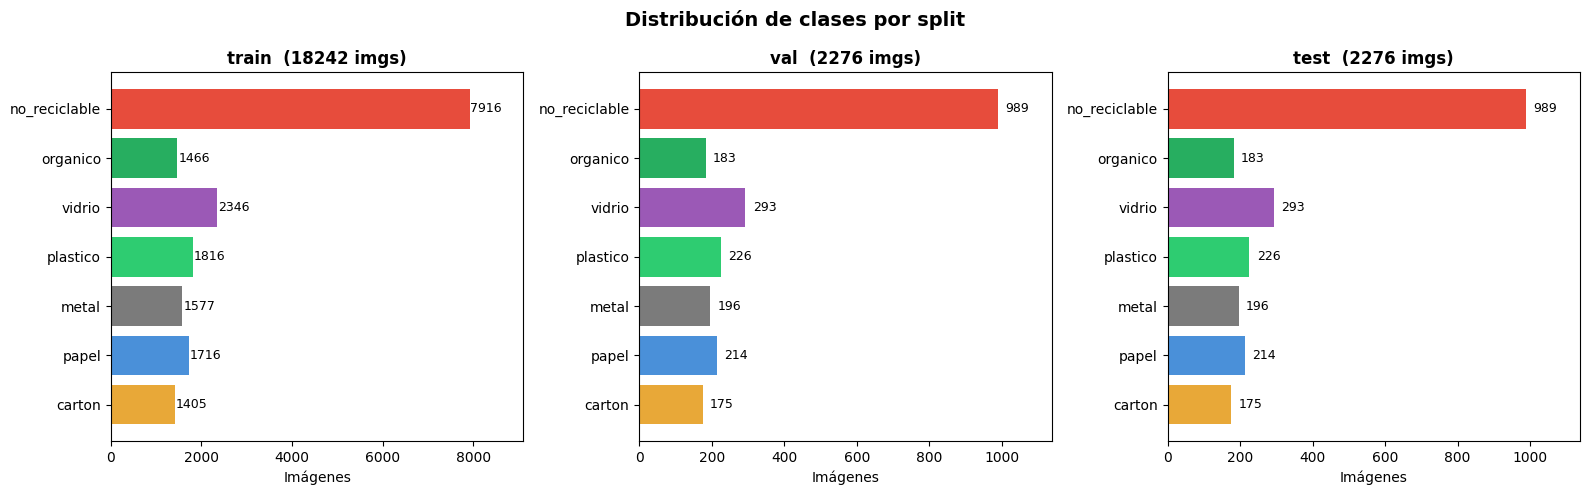

Guardado: class_distribution.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribución de clases por split', fontsize=14, fontweight='bold')

for ax, split in zip(axes, ['train', 'val', 'test']):
    subset = df[df['split'] == split]
    conteo = subset['clase'].value_counts().reindex(CLASSES)
    bars = ax.barh(CLASSES, conteo.values, color=COLORES)
    ax.set_title(f'{split}  ({len(subset)} imgs)', fontweight='bold')
    ax.set_xlabel('Imágenes')
    for bar, val in zip(bars, conteo.values):
        ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=9)
    ax.set_xlim(0, conteo.max() * 1.15)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, 'class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: class_distribution.png")

# Celda 4 — Desbalance en porcentaje (solo train)


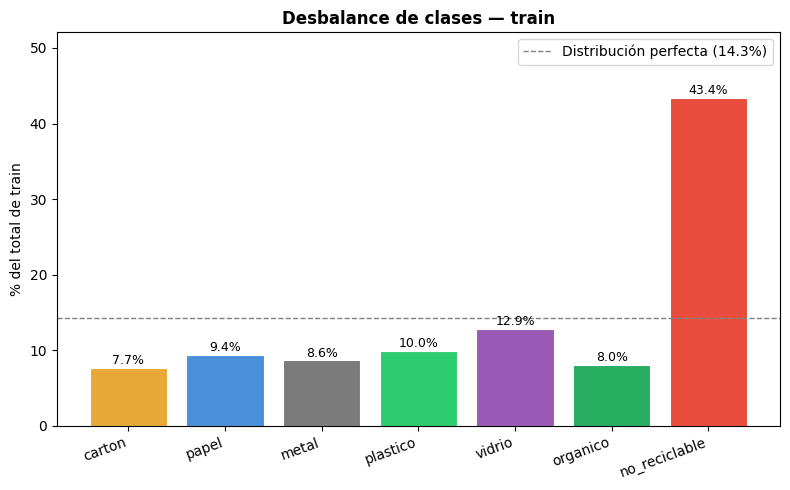

In [5]:
train_df = df[df['split'] == 'train']
conteo   = train_df['clase'].value_counts().reindex(CLASSES)
pcts     = conteo / conteo.sum() * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(CLASSES, pcts.values, color=COLORES, edgecolor='white', linewidth=0.8)
ax.axhline(100/7, color='gray', linestyle='--', linewidth=1, label=f'Distribución perfecta ({100/7:.1f}%)')
ax.set_ylabel('% del total de train')
ax.set_title('Desbalance de clases — train', fontweight='bold')
ax.legend()
ax.set_ylim(0, pcts.max() * 1.2)
for bar, pct in zip(bars, pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{pct:.1f}%', ha='center', fontsize=9)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, 'class_imbalance.png'), dpi=150, bbox_inches='tight')
plt.show()

# Celda 5 — Muestrear y analizar resoluciones (muestra de 1000 imgs)

Esta celda abre imágenes reales, así que tarda 1-2 minutos.


In [6]:
muestra = df.sample(n=1000, random_state=42)

anchos, altos, aspect_ratios, tamanos = [], [], [], []

for _, row in muestra.iterrows():
    try:
        with Image.open(row['ruta']) as img:
            w, h = img.size
            anchos.append(w)
            altos.append(h)
            aspect_ratios.append(round(w/h, 2))
            tamanos.append(row['clase'])
    except:
        pass

print(f"Imágenes analizadas: {len(anchos)}")
print(f"\nAncho  — min: {min(anchos)}  max: {max(anchos)}  media: {np.mean(anchos):.0f}")
print(f"Alto   — min: {min(altos)}  max: {max(altos)}  media: {np.mean(altos):.0f}")
print(f"Aspect — min: {min(aspect_ratios):.2f}  max: {max(aspect_ratios):.2f}  media: {np.mean(aspect_ratios):.2f}")

Imágenes analizadas: 1000

Ancho  — min: 51  max: 867  media: 401
Alto   — min: 126  max: 888  media: 388
Aspect — min: 0.13  max: 3.17  media: 1.10


# Celda 6 — Histogramas de resolución


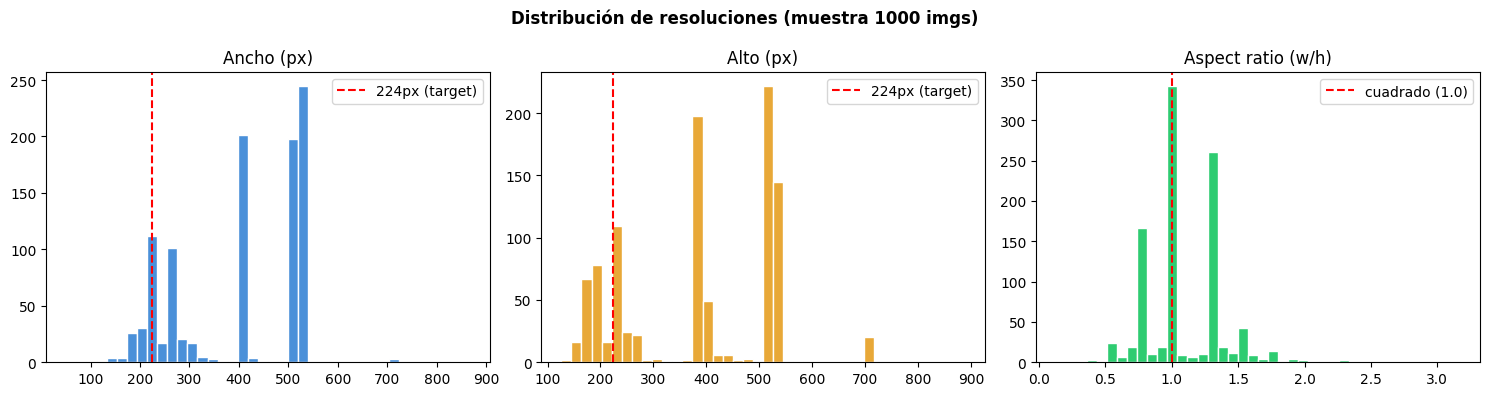

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribución de resoluciones (muestra 1000 imgs)', fontweight='bold')

axes[0].hist(anchos, bins=40, color='#4A90D9', edgecolor='white')
axes[0].set_title('Ancho (px)')
axes[0].axvline(224, color='red', linestyle='--', label='224px (target)')
axes[0].legend()

axes[1].hist(altos, bins=40, color='#E8A838', edgecolor='white')
axes[1].set_title('Alto (px)')
axes[1].axvline(224, color='red', linestyle='--', label='224px (target)')
axes[1].legend()

axes[2].hist(aspect_ratios, bins=40, color='#2ECC71', edgecolor='white')
axes[2].set_title('Aspect ratio (w/h)')
axes[2].axvline(1.0, color='red', linestyle='--', label='cuadrado (1.0)')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, 'resolution_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

# Celda 7 — Grid de muestras visuales por clase


In [8]:
N_MUESTRAS = 5
fig, axes = plt.subplots(len(CLASSES), N_MUESTRAS, figsize=(15, 22))
fig.suptitle('Muestras por clase', fontsize=15, fontweight='bold', y=1.01)

for i, clase in enumerate(CLASSES):
    clase_df = df[(df['clase'] == clase) & (df['split'] == 'train')]
    muestras = clase_df.sample(n=min(N_MUESTRAS, len(clase_df)), random_state=i)

    for j, (_, row) in enumerate(muestras.iterrows()):
        ax = axes[i][j]
        try:
            img = Image.open(row['ruta']).convert('RGB')
            img_resized = img.resize((224, 224))
            ax.imshow(img_resized)
        except:
            ax.set_facecolor('#eee')
        ax.axis('off')
        if j == 0:
            ax.set_ylabel(clase, fontsize=11, fontweight='bold',
                         rotation=0, labelpad=80, va='center')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, 'samples_per_class.png'), dpi=120, bbox_inches='tight')
plt.show()
print("Guardado: samples_per_class.png")

Output hidden; open in https://colab.research.google.com to view.

# Celda 8 — Class weights (recordatorio visual)


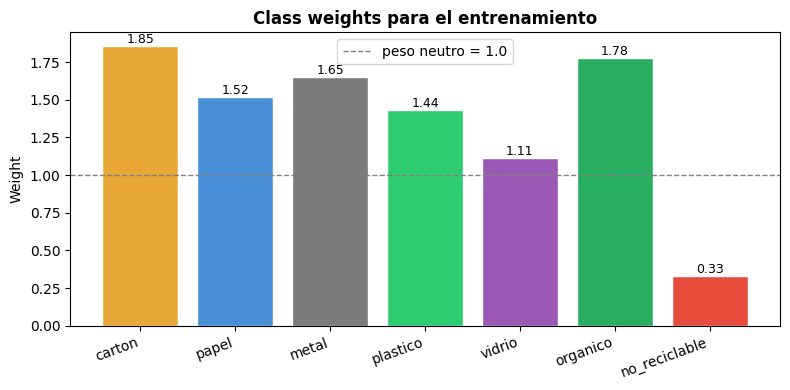

In [9]:
with open(os.path.join(METADATA, 'class_weights.json')) as f:
    weights = json.load(f)

fig, ax = plt.subplots(figsize=(8, 4))
clases_w = list(weights.keys())
vals_w   = list(weights.values())
bars = ax.bar(clases_w, vals_w, color=COLORES, edgecolor='white')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='peso neutro = 1.0')
ax.set_title('Class weights para el entrenamiento', fontweight='bold')
ax.set_ylabel('Weight')
ax.legend()
for bar, v in zip(bars, vals_w):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{v:.2f}', ha='center', fontsize=9)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, 'class_weights.png'), dpi=150, bbox_inches='tight')
plt.show()

# Celda 9 — Resumen final del EDA


In [10]:
print("=" * 50)
print("RESUMEN EDA")
print("=" * 50)
print(f"\nTotal imágenes:      {len(df)}")
print(f"  Train:             {len(df[df.split=='train'])}")
print(f"  Val:               {len(df[df.split=='val'])}")
print(f"  Test:              {len(df[df.split=='test'])}")
print(f"\nClases:              {len(CLASSES)}")
print(f"Clase más frecuente: no_reciclable ({pcts['no_reciclable']:.1f}%)")
print(f"Clase menos frec.:   carton ({pcts['carton']:.1f}%)")
print(f"\nResolución media:    {np.mean(anchos):.0f} x {np.mean(altos):.0f} px")
print(f"Resize target:       224 x 224 px")
print(f"\nDesbalance ratio:    {pcts.max()/pcts.min():.1f}x")
print(f"  → Se compensará con class_weights en el entrenamiento")
print(f"\nPlots guardados en:  {OUTPUTS}")
print("=" * 50)
print("\nEDA completo. Siguiente paso: Notebook 03 — Preprocessing y DataLoaders")

RESUMEN EDA

Total imágenes:      22794
  Train:             18242
  Val:               2276
  Test:              2276

Clases:              7
Clase más frecuente: no_reciclable (43.4%)
Clase menos frec.:   carton (7.7%)

Resolución media:    401 x 388 px
Resize target:       224 x 224 px

Desbalance ratio:    5.6x
  → Se compensará con class_weights en el entrenamiento

Plots guardados en:  /content/drive/MyDrive/project_factoria/waste_classifier/outputs

EDA completo. Siguiente paso: Notebook 03 — Preprocessing y DataLoaders
